In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("senju14/ocr-dataset-of-multi-type-documents")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/senju14/ocr-dataset-of-multi-type-documents


In [17]:
import numpy as np
from pathlib import Path
import shutil
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [18]:
dataset_path= Path("/kaggle/input/datasets/senju14/ocr-dataset-of-multi-type-documents")
all_folders= [folder for folder in dataset_path.iterdir()]
print(all_folders[0])
real_life_train = all_folders[0] / "train"
real_life_val = all_folders[0] / "val"
real_life_test = all_folders[0] / "test"
real_life_train_annots= real_life_train / "annotations"
real_life_train_imgs = real_life_train / "images"

/kaggle/input/datasets/senju14/ocr-dataset-of-multi-type-documents/real_life


In [19]:
annot_path = real_life_train_annots / "poly_gt_img1009.txt"
img_path = real_life_train_imgs / "img1009.jpg"
print(img_path)

/kaggle/input/datasets/senju14/ocr-dataset-of-multi-type-documents/real_life/train/images/img1009.jpg


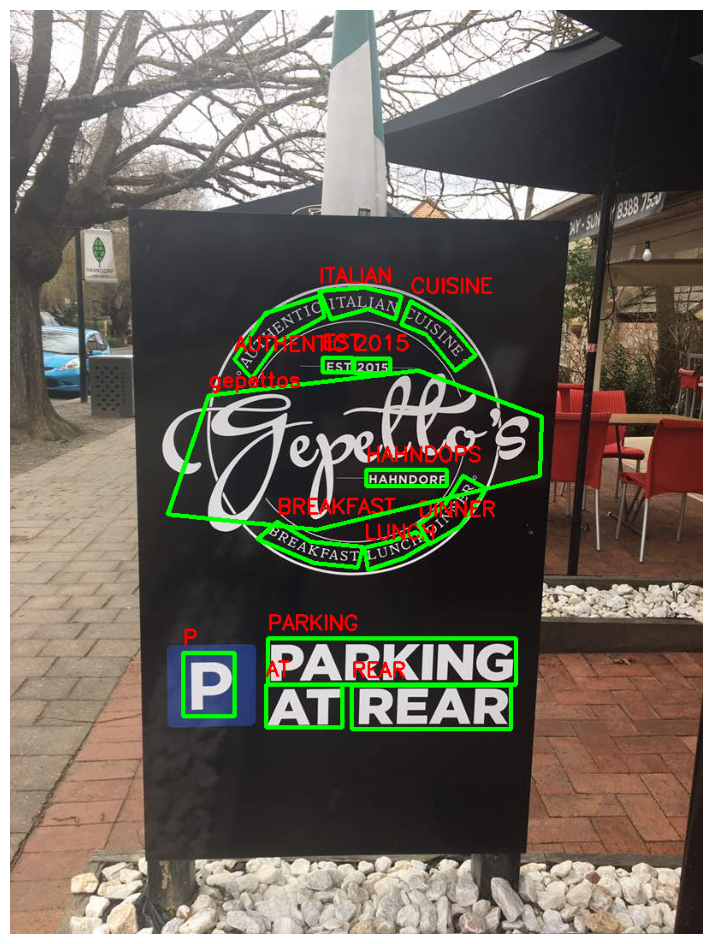

In [20]:
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
with open(annot_path , "r") as f:
    lines = f.readlines()

for line in lines:
    if not line.strip():
        continue
    # Python wizardry to safely extract the lists from the text strings
    # We split by the keys to isolate the numbers
    parts = line.split(", ornt:")
    coords_part = parts[0]
    trans_part = line.split("transcriptions: [u'")[-1].split("']")[0]
    
    x_str = coords_part.split("x: [[")[-1].split("]]")[0]
    y_str = coords_part.split("y: [[")[-1].split("]]")[0]
    
    # Convert string numbers into actual Python integer lists
    x_coords = [int(x) for x in x_str.split()]
    y_coords = [int(y) for y in y_str.split()]
    
    # Pair up X and Y coordinates into [[x1, y1], [x2, y2], ...]
    points = np.array(list(zip(x_coords, y_coords)), dtype=np.int32)
    
    # Reshape for OpenCV's polygon drawer
    points = points.reshape((-1, 1, 2))
    
    # 4. Draw the polygon (Green lines)
    cv2.polylines(image, [points], isClosed=True, color=(0, 255, 0), thickness=3)
    
    # Put the transcribed text (e.g., "GEMBIRA") near the first coordinate
    cv2.putText(image, trans_part, (x_coords[0], y_coords[0] - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

# 5. Display it!
plt.figure(figsize=(12, 12))
plt.imshow(image)
plt.axis('off')
plt.show()

In [5]:
import os
import re
import cv2

# 1. Define your Kaggle dataset paths
# (We will do the 'train' folder first as an example)
base_dir = "/kaggle/input/datasets/senju14/ocr-dataset-of-multi-type-documents/real_life/train"
annot_dir = os.path.join(base_dir, "annotations")
images_dir = os.path.join(base_dir, "images")

# 2. Create the output folder where YOLO will look for labels
output_label_dir = "/kaggle/working/yolo_dataset/labels/train"
os.makedirs(output_label_dir, exist_ok=True)

# 3. Process every annotation file
for filename in os.listdir(annot_dir):
    if not filename.endswith(".txt"):
        continue
        
    txt_path = os.path.join(annot_dir, filename)
    
    # Map the annotation file back to its original image
    img_filename = filename.replace("poly_gt_", "").replace(".txt", ".jpg")
    img_path = os.path.join(images_dir, img_filename)
    
    # Make sure the image actually exists before processing
    if not os.path.exists(img_path):
        continue 
        
    # Read the image to get its width and height for normalization
    img = cv2.imread(img_path)
    img_height, img_width, _ = img.shape
    
    yolo_segmentation_lines = []
    
    # Open and read the crazy coordinate file
    with open(txt_path, 'r') as f:
        for line in f:
            if "transcriptions" not in line:
                continue
                
            # Regex trick to grab everything inside the double brackets [[ ]]
            x_match = re.search(r'x:\s*\[\[(.*?)\]\]', line)
            y_match = re.search(r'y:\s*\[\[(.*?)\]\]', line)
            
            if x_match and y_match:
                # Convert the space-separated strings into lists of integers
                x_coords = [int(x) for x in x_match.group(1).split()]
                y_coords = [int(y) for y in y_match.group(1).split()]
                
                # Zip X and Y together, normalize them, and format to 6 decimal places
                normalized_pairs = []
                for x, y in zip(x_coords, y_coords):
                    norm_x = x / img_width
                    norm_y = y / img_height
                    normalized_pairs.append(f"{norm_x:.6f} {norm_y:.6f}")
                
                # Combine them into the final YOLO format: "class_id x1 y1 x2 y2..."
                polygon_string = " ".join(normalized_pairs)
                yolo_segmentation_lines.append(f"0 {polygon_string}\n")
                
    # 4. Save the freshly formatted text file to your working directory
    output_filename = img_filename.replace(".jpg", ".txt")
    output_path = os.path.join(output_label_dir, output_filename)
    
    if yolo_segmentation_lines:
        with open(output_path, 'w') as out_f:
            out_f.writelines(yolo_segmentation_lines)

print("🎉 Success! Your YOLO Segmentation labels are ready at: /kaggle/working/yolo_dataset/labels/train")

🎉 Success! Your YOLO Segmentation labels are ready at: /kaggle/working/yolo_dataset/labels/train


In [6]:
import os

# Create the images directory right next to your labels directory
output_img_dir = "/kaggle/working/yolo_dataset/images/train"
os.makedirs(output_img_dir, exist_ok=True)

# Path to your original dataset images
original_images_dir = "/kaggle/input/datasets/senju14/ocr-dataset-of-multi-type-documents/real_life/train/images"

# Create virtual links from the original images to our new YOLO folder
for img_name in os.listdir(original_images_dir):
    src = os.path.join(original_images_dir, img_name)
    dst = os.path.join(output_img_dir, img_name)
    if not os.path.exists(dst):
        os.symlink(src, dst)

print("✅ Image shortcuts created! Your dataset folder structure is completely ready.")

✅ Image shortcuts created! Your dataset folder structure is completely ready.


In [7]:
yaml_content = """
path: /kaggle/working/yolo_dataset # dataset root dir
train: images/train # train images (relative to 'path')
val: images/train   # using train as val just to get started simply

# Classes
names:
  0: text_region
"""

with open("/kaggle/working/dataset.yaml", "w") as f:
    f.write(yaml_content.strip())

print("✅ dataset.yaml created successfully!")

✅ dataset.yaml created successfully!


In [21]:
!pip install ultralytics

In [9]:
from ultralytics import YOLO

# 1. Load a pre-trained YOLOv11 Segmentation Nano model
model = YOLO("yolo11n-seg.pt")

# 2. Train the model using the custom dataset configuration
results = model.train(
    data="/kaggle/working/dataset.yaml", # Path to your yaml file
    epochs=25,                           # Start with 25 epochs to see progress
    imgsz=640,                           # Standard input image size
    device=0,                            # Use GPU (0 is usually the first GPU in Kaggle)
    workers=2                            # Number of CPU workers for data loading
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.56 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz

In [10]:
from ultralytics import YOLO

# 1. Load the last saved weights from your previous 25-epoch run
model = YOLO("/kaggle/working/runs/segment/train/weights/last.pt")

# 2. Resume training to build on top of what it already learned
results = model.train(
    data="/kaggle/working/dataset.yaml",
    epochs=25,       # Total target epochs (adds 50 more epochs to your original 25)
    resume=True      # Tells YOLO to continue from the saved state
)

WARNING ⚠️ model '/kaggle/working/runs/segment/train/weights/last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.56 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, 

In [11]:
from ultralytics import YOLO

# 1. Load the absolute best weights from your successful train-2 run
model = YOLO("/kaggle/working/runs/segment/train-2/weights/best.pt")

# 2. Start a new fine-tuning run with a tightly controlled, small learning rate
results = model.train(
    data="/kaggle/working/dataset.yaml",
    epochs=30,               # Run it for another 30 epochs
    imgsz=640,
    device=0,
    lr0=0.0005,              # Manually setting a low, stable starting learning rate
    lrf=0.01,                # Final learning rate fraction
    optimizer='AdamW'        # Explicitly using AdamW for stable fine-tuning
)

Ultralytics 8.4.56 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/runs/segment/train-2/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimi

In [64]:
image_path = "/kaggle/input/datasets/senju14/ocr-dataset-of-multi-type-documents/real_life/val/images/img168.jpg"


image 1/1 /kaggle/input/datasets/senju14/ocr-dataset-of-multi-type-documents/real_life/val/images/img168.jpg: 416x640 3 text_regions, 142.8ms
Speed: 2.2ms preprocess, 142.8ms inference, 3.9ms postprocess per image at shape (1, 3, 416, 640)

--- Processing Predictions ---
🎯 Found 3 text region(s)!


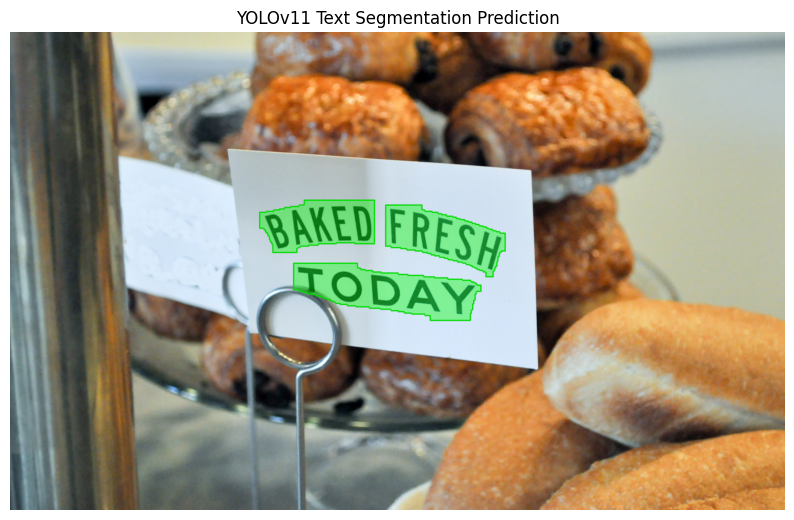

In [65]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load your absolute best fine-tuned model
model = YOLO("/kaggle/input/models/rehmang110/bestmodel/pytorch/default/1/best.pt")

# 2. Path to the image you want to test
# Replace this with the path to any image you want to test!
image_path = image_path

# Read the original image using OpenCV
img = cv2.imread(image_path)
# Create a clean copy specifically for drawing our visualization overlay
overlay = img.copy()

# 3. Run Inference
# We set conf=0.25 to ignore any weak, uncertain predictions
results = model.predict(source=image_path, conf=0.25)

print("\n--- Processing Predictions ---")

# Loop through the results (YOLO returns a list, one item per image)
for result in results:
    # Check if the model actually found any masks in this image
    if result.masks is None:
        print("❌ No text regions detected in this image.")
        continue
    
    # Get the polygon coordinate points for every detected mask
    # result.masks.xy provides a list of coordinate arrays [[x1, y1], [x2, y2], ...]
    masks_xy = result.masks.xy
    
    print(f"🎯 Found {len(masks_xy)} text region(s)!")
    
    for i, poly_coords in enumerate(masks_xy):
        # Convert coordinates into a standard NumPy integer format that OpenCV understands
        pts = np.array(poly_coords, dtype=np.int32).reshape((-1, 1, 2))
        
        # Draw a solid colored polygon on our overlay image layer
        # (0, 255, 0) represents Green in BGR format
        cv2.fillPoly(overlay, [pts], color=(0, 255, 0))
        
        # Draw a slightly darker green outline around the polygon border to make it pop
        cv2.polylines(img, [pts], isClosed=True, color=(0, 200, 0), thickness=2)

# 4. Blend the overlay with the original image
# alpha controls the transparency of the background (0.6 = 60% original image)
# beta controls the transparency of the mask layer (0.4 = 40% mask color opacity)
alpha = 0.6
beta = 1.0 - alpha
final_visualization = cv2.addWeighted(img, alpha, overlay, beta, 0)

# 5. Convert from BGR (OpenCV standard) to RGB (Matplotlib standard) and display
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(final_visualization, cv2.COLOR_BGR2RGB))
plt.title("YOLOv11 Text Segmentation Prediction")
plt.axis('off') # Hide pixel grid axes for a clean look
plt.show()

In [30]:
# 1. Install EasyOCR cleanly
!pip install easyocr --quiet


Using CPU. Note: This module is much faster with a GPU.


📸 Document target loaded: /kaggle/input/datasets/senju14/ocr-dataset-of-multi-type-documents/real_life/val/images/img168.jpg
⏳ Loading AI frameworks onto CPU memory...

image 1/1 /kaggle/input/datasets/senju14/ocr-dataset-of-multi-type-documents/real_life/val/images/img168.jpg: 416x640 3 text_regions, 110.4ms
Speed: 2.3ms preprocess, 110.4ms inference, 3.5ms postprocess per image at shape (1, 3, 416, 640)
🎯 Successfully targeted 3 text region(s). Running OCR...

--- 📝 Transcribed Segment 1 ---
Parsed Content: "BAKEd" (Confidence: 0.70)


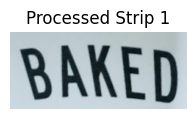

--------------------------------------------------
--- 📝 Transcribed Segment 2 ---
Parsed Content: "TODAY" (Confidence: 0.98)


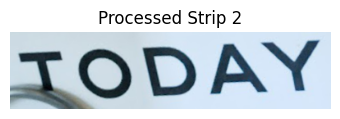

--------------------------------------------------
--- 📝 Transcribed Segment 3 ---
Parsed Content: "FRESH" (Confidence: 1.00)


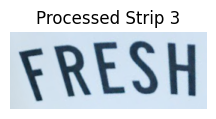

--------------------------------------------------


In [66]:

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import easyocr

# =====================================================================
# 🔥 DEFINED DATASET PATH
# =====================================================================
IMAGE_PATH =image_path
# =====================================================================

# 2. Path verification
if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(f"❌ Target image file not found at: {IMAGE_PATH}")

print(f"📸 Document target loaded: {IMAGE_PATH}")
original_img = cv2.imread(IMAGE_PATH)

print("⏳ Loading AI frameworks onto CPU memory...")
# Force YOLO to load directly onto the CPU by specifying device='cpu'
yolo_model = YOLO("/kaggle/input/models/rehmang110/bestmodel/pytorch/default/1/best.pt")

# Force EasyOCR to run on CPU by setting gpu=False
ocr_reader = easyocr.Reader(['en'], gpu=False)

def extract_and_flatten_text(image, polygon_points):
    """
    Converts multi-point contours from YOLO into a strictly ordered, 
    non-inverted 4-corner perspective warp.
    """
    pts = np.array(polygon_points, dtype=np.int32).reshape((-1, 1, 2))
    
    # 1. Get the 4 raw corners from OpenCV
    rect = cv2.minAreaRect(pts)
    box = cv2.boxPoints(rect)
    box = np.array(box, dtype="float32")
    
    # 2. 🔥 THE FIX: Sort the 4 corners strictly so they NEVER mirror or invert
    # Sum of coordinates (x + y): Top-Left has the smallest sum, Bottom-Right has the largest sum
    coord_sum = box.sum(axis=1)
    # Difference of coordinates (y - x): Top-Right has the smallest diff, Bottom-Left has the largest
    coord_diff = np.diff(box, axis=1).flatten()
    
    # Allocate points to explicit, unchangeable positions
    ordered_box = np.zeros((4, 2), dtype="float32")
    ordered_box[0] = box[np.argmin(coord_sum)]   # Strict Top-Left
    ordered_box[2] = box[np.argmax(coord_sum)]   # Strict Bottom-Right
    ordered_box[1] = box[np.argmin(coord_diff)]  # Strict Top-Right
    ordered_box[3] = box[np.argmax(coord_diff)]  # Strict Bottom-Left
    
    # 3. Calculate accurate distances using the properly sorted coordinates
    width_top = np.linalg.norm(ordered_box[1] - ordered_box[0])
    width_bottom = np.linalg.norm(ordered_box[2] - ordered_box[3])
    max_width = max(int(width_top), int(width_bottom))
    
    height_left = np.linalg.norm(ordered_box[3] - ordered_box[0])
    height_right = np.linalg.norm(ordered_box[2] - ordered_box[1])
    max_height = max(int(height_left), int(height_right))
    
    # 4. Map directly to a flat horizontal grid
    dst_pts = np.array([
        [0, 0],
        [max_width - 1, 0],
        [max_width - 1, max_height - 1],
        [0, max_height - 1]
    ], dtype="float32")
    
    # 5. Execute warp
    matrix = cv2.getPerspectiveTransform(ordered_box, dst_pts)
    warped_strip = cv2.warpPerspective(image, matrix, (max_width, max_height))
    
    return warped_strip

# 3. Predict Text Coordinates using YOLOv11-seg on CPU
results = yolo_model.predict(source=IMAGE_PATH, conf=0.25, device='cpu')

# 4. Extract, Flat-map, and Transcribe Strings
for result in results:
    if result.masks is None:
        print("❌ YOLO did not catch any distinct text regions.")
        continue
        
    masks_xy = result.masks.xy
    print(f"🎯 Successfully targeted {len(masks_xy)} text region(s). Running OCR...\n")
    
    for i, poly_coords in enumerate(masks_xy):
        if len(poly_coords) < 3:
            continue
            
        # Get the flat text strip crop
        cropped_text_strip = extract_and_flatten_text(original_img, poly_coords)
        
        if cropped_text_strip.size == 0:
            continue
            
        # Run EasyOCR text recognition on the horizontal crop
        ocr_result = ocr_reader.readtext(cropped_text_strip)
        
        print(f"--- 📝 Transcribed Segment {i+1} ---")
        if ocr_result:
            for (bbox, text_string, confidence) in ocr_result:
                print(f"Parsed Content: \"{text_string}\" (Confidence: {confidence:.2f})")
        else:
            print("No text could be clearly parsed in this segment.")
            
        # Display the flat crop slice for visual verification
        plt.figure(figsize=(6, 1))
        plt.imshow(cv2.cvtColor(cropped_text_strip, cv2.COLOR_BGR2RGB))
        plt.title(f"Processed Strip {i+1}")
        plt.axis('off')
        plt.show()
        print("-" * 50)